# Notebook de pruebas para llegar a un resultado final del analisis de datos de Pimpamboing

# intalacion de libreria

In [1]:
!pip install folium pandas plotly

# Para esta prueba se genero el dataset directamente en la celda, solo para analizar en mapa que tendriamos como resultado, usando la coordenadas que sacamos de google maps

In [3]:
import pandas as pd
from io import StringIO

datos_puebla = """Ubicacion,Latitud,Longitud,Ventas,Instalaciones
Punto_Xicotepec_1,20.315303675011258,-97.87223683107658,2,3
Punto_Zacatlan,20.031584268367386,-98.26122287143225,2,3
Punto_Huauchinango,20.219519906470598,-98.35014346026067,2,3
Punto_Xicotepec_2,20.354899224535316,-97.87636014846592,1,10
Punto_Chignahuapan,19.98287121165811,-98.05900577946342,1,10
Punto_Teziutlan,20.184056447502478,-98.06435128199519,5,30
Punto_Cholula,19.35515935095567,-98.11763927185629,5,30
Punto_Puebla_Centro,19.13696295389625,-98.33030214359589,5,30
Punto_Amozoc,19.029592310264878,-97.73504031539325,5,30
Punto_San_Martin,19.457739311888197,-98.02150400106989,5,30
Punto_Libres,20.16724225096794,-98.05618564516854,3,5
Punto_Zaragoza,20.112846597911307,-98.11737064471757,3,5
Punto_Cuetzalan,20.1811344523573,-98.04536617637326,1,3
Punto_Atlixco,19.988573708231893,-98.29878725867614,1,3
Punto_Tehuacan,20.189395469558267,-98.06678503098803,0,5
Punto_Izucar,20.165460908323535,-98.0576463724521,0,8
Punto_Tecamachalco,20.064803721494158,-98.23375705248911,0,12
Punto_Tepeaca,19.32232417344862,-97.51534143620135,0,15
Punto_Grajales,19.419429996205178,-97.37842150508135,0,4"""

df = pd.read_csv(StringIO(datos_puebla))

lat_centro = 19.7000
lon_centro = -97.9500

print("¡Dataset cargado y listo!")
df.head()

¡Dataset cargado y listo!


,Ubicacion,Latitud,Longitud,Ventas,Instalaciones
0,Punto_Xicotepec_1,20.315304,-97.872237,2,3
1,Punto_Zacatlan,20.031584,-98.261223,2,3
2,Punto_Huauchinango,20.219520,-98.350143,2,3
3,Punto_Xicotepec_2,20.354899,-97.876360,1,10
4,Punto_Chignahuapan,19.982871,-98.059006,1,10


In [ ]:
# Mapa simulando ventas

In [8]:
import folium


mapa_ventas = folium.Map(location=[lat_centro, lon_centro], tiles='CartoDB dark_matter', zoom_start=8.5)

for index, fila in df.iterrows():
    if fila['Ventas'] == 0:
        continue  
        
    radio_v = fila['Ventas'] * 4
    popup_text = f"<b> {fila['Ubicacion']}</b><br> Ventas Merch: {int(fila['Ventas'])}"
    
    folium.CircleMarker(
        location=[fila['Latitud'], fila['Longitud']],
        popup=popup_text,
        radius=radio_v,
        color='#be0eef',
        fill=True,
        fill_color='#be0eef',
        fill_opacity=0.6
    ).add_to(mapa_ventas)


mapa_instalaciones = folium.Map(location=[lat_centro, lon_centro], tiles='CartoDB dark_matter', zoom_start=8.5)

for index, fila in df.iterrows():
    radio_i = fila['Instalaciones'] * 0.8
    popup_text = f"<b> {fila['Ubicacion']}</b><br>nstalaciones: {int(fila['Instalaciones'])}"
    
    folium.CircleMarker(
        location=[fila['Latitud'], fila['Longitud']],
        popup=popup_text,
        radius=radio_i,
        color='#00f3ff',
        fill=True,
        fill_color='#00f3ff',
        fill_opacity=0.5
    ).add_to(mapa_instalaciones)


mapa_ventas

# Simulando solo descargas

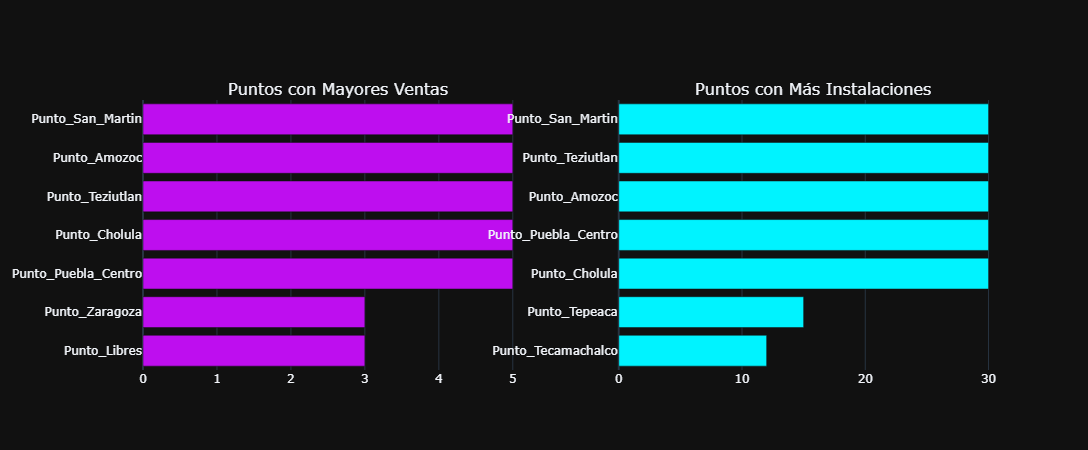

In [6]:
import plotly.graph_objs as go
from plotly import subplots


def generar_trazo(df, col_valores, color, limit=7):
    df_ordenado = df.sort_values(by=col_valores, ascending=True).tail(limit)
    return go.Bar(
        y=df_ordenado['Ubicacion'], 
        x=df_ordenado[col_valores], 
        orientation='h', 
        marker=dict(color=color),
        name=col_valores
    )

trace_v = generar_trazo(df, 'Ventas', '#be0eef', limit=7)
trace_i = generar_trazo(df, 'Instalaciones', '#00f3ff', limit=7)

fig = subplots.make_subplots(
    rows=1, cols=2, 
    subplot_titles=['Puntos con Mayores Ventas', 'Puntos con Más Instalaciones'],
    shared_yaxes=False
)

fig.append_trace(trace_v, 1, 1)
fig.append_trace(trace_i, 1, 2)

fig['layout'].update(
    height=450, 
    width=950, 
    showlegend=False,
    template='plotly_dark'
)

fig.show()

In [9]:
import folium

lat_centro = 19.7000
lon_centro = -97.9500

mapa_instalaciones = folium.Map(location=[lat_centro, lon_centro], tiles='CartoDB dark_matter', zoom_start=8.5)

for index, fila in df.iterrows():
    radio_i = fila['Instalaciones'] * 0.8
    popup_text = f"<b> {fila['Ubicacion']}</b><br>Instalaciones: {int(fila['Instalaciones'])}"
    
    folium.CircleMarker(
        location=[fila['Latitud'], fila['Longitud']],
        popup=popup_text,
        radius=radio_i,
        color='#00f3ff',
        fill=True,
        fill_color='#00f3ff',
        fill_opacity=0.6
    ).add_to(mapa_instalaciones)

mapa_instalaciones

In [ ]:
# Conclusion de las Pruebas:
## Lo que logramos analizar fue 